In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Download the datasets from HF via CLI (Notice the /data/ path in the URL)
!wget https://huggingface.co/datasets/chriamue/bird-species-dataset/resolve/main/data/train.tar.gz
!wget https://huggingface.co/datasets/chriamue/bird-species-dataset/resolve/main/data/valid.tar.gz
!wget https://huggingface.co/datasets/chriamue/bird-species-dataset/resolve/main/data/test.tar.gz

# Extract the compressed archives
!tar -xzf train.tar.gz
!tar -xzf valid.tar.gz
!tar -xzf test.tar.gz

# Clean up to save GC VM disk space
!rm train.tar.gz valid.tar.gz test.tar.gz

--2026-03-13 11:36:57--  https://huggingface.co/datasets/chriamue/bird-species-dataset/resolve/main/data/train.tar.gz
Resolving huggingface.co (huggingface.co)... 3.168.132.40, 3.168.132.91, 3.168.132.38, ...
Connecting to huggingface.co (huggingface.co)|3.168.132.40|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/653e23d36217d355c6959b35/7386de21da5ce91c4a017c143652a0f89d888f143fb8b417fe2ddf0e0a5c761d?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27train.tar.gz%3B+filename%3D%22train.tar.gz%22%3B&response-content-type=application%2Fgzip&Expires=1773405417&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzczNDA1NDE3fX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjUzZTIzZDM2MjE3ZDM1NWM2OTU5YjM1LzczODZkZTIxZGE1Y2U5MWM0YTAxN2MxNDM2NTJhMGY4OWQ4ODhmMTQzZmI4YjQxN2ZlMmRkZjBlMGE1Yzc2MWRcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomcmVzcG9uc2UtY29udGVudC

In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms , models

In [4]:
train_path = "/content/train/"
val_path = "/content/valid/"
test_path = "/content/test/"
n_train = len(os.listdir(train_path))
print("The number of classes are" , n_train)

The number of classes are 525


Species: SWINHOES PHEASANT


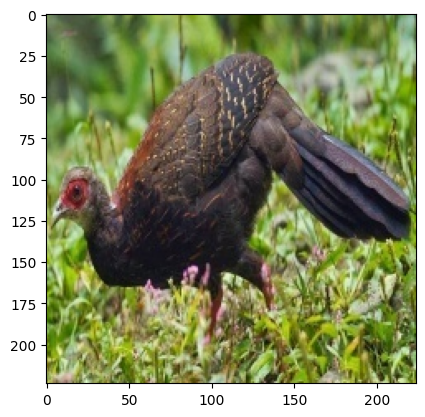

In [5]:
#Display a random image from the train dataset
fold = np.random.choice(os.listdir(train_path))
all_imgs = os.listdir(train_path + fold)
img_name = np.random.choice(all_imgs)
img = cv2.imread(train_path + fold + "/" + img_name)
img = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
print("Species:" , fold)
plt.imshow(img)
plt.show()

In [6]:
#Hyperparameters
BATCH_SIZE = 64
LR = 0.001
NUM_EPOCHS = 5

In [7]:
#Transforms
transform = transforms.Compose([
    transforms.ToTensor() , 
    transforms.Resize((224 , 224) , antialias = True) , 
    transforms.Normalize(mean=[0.485, 0.456, 0.406] , std=[0.229, 0.224, 0.225])
])

In [8]:
#Dataset
train_dataset = torchvision.datasets.ImageFolder(root = train_path , transform = transform)
val_dataset = torchvision.datasets.ImageFolder(root = val_path , transform = transform)
test_dataset = torchvision.datasets.ImageFolder(root = test_path , transform = transform)

In [9]:
#DataLoader
train_loader = torch.utils.data.DataLoader(train_dataset , shuffle = True , batch_size = BATCH_SIZE)
val_loader = torch.utils.data.DataLoader(val_dataset , shuffle = False , batch_size = BATCH_SIZE , drop_last = True)
test_loader = torch.utils.data.DataLoader(test_dataset , shuffle = False , batch_size = BATCH_SIZE)

In [10]:
#Model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze the foundational TL layers so they don't consume compute
for param in model.parameters():
    param.requires_grad = False

final_layer_infeatures = model.fc.in_features
model.fc = nn.Linear(final_layer_infeatures , n_train)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [12]:
fin_model = model.to(device)

In [13]:
#Optimizer and Loss function
optimizer = torch.optim.Adam(model.parameters() , lr = LR)
loss_fn = nn.CrossEntropyLoss()

In [14]:
all_train_losses = []
all_val_losses = []

for EPOCH in range(NUM_EPOCHS):
    train_epoch_loss = 0
    total_train_samples = 0
    total_train_correct = 0
    for (images , labels) in train_loader:
        total_train_samples += images.shape[0]
        fin_model.train()
        if torch.cuda.is_available():
            images = images.to(device)
            labels = labels.to(device)
        output = fin_model(images)
        loss = loss_fn(output , labels)
        
        train_epoch_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        fin_model.eval()
        with torch.no_grad():
            _ , indices = torch.max(output , dim = 1)
            total_train_correct += (indices == labels).sum().item()
            
    #Validation
    val_epoch_loss = 0
    total_val_samples = 0
    total_val_correct = 0
    fin_model.eval()
    with torch.no_grad():
        for (images , labels) in val_loader:
            total_val_samples += images.shape[0]
            if torch.cuda.is_available():
                images = images.to(device)
                labels = labels.to(device)
            output = fin_model(images)
            loss = loss_fn(output , labels)

            val_epoch_loss += loss.item()

            
            _ , indices = torch.max(output , dim = 1)
            total_val_correct += (indices == labels).sum().item()
            
            
    train_loss = train_epoch_loss / total_train_samples
    val_loss = val_epoch_loss / total_val_samples
    train_accuracy = total_train_correct / total_train_samples
    val_accuracy = total_val_correct / total_val_samples
    
    all_train_losses.append(train_loss)
    all_val_losses.append(val_loss)
    
    print(train_loss , " " , val_loss , " " , train_accuracy , " " , val_accuracy)

0.03349891595792001   0.01183504911094177   0.6173214391209311   0.8452743902439024
0.011905351876789972   0.008089902362127492   0.8327405919536834   0.8822408536585366
0.008692597799034375   0.006991373755537518   0.8683168901754593   0.885670731707317
0.007009580753399884   0.006574181254907716   0.8911325101908194   0.8898628048780488
0.005950920775980805   0.006609192924437727   0.9049683936905536   0.8898628048780488


In [15]:
#Testing accruacy
total_test_samples = 0
total_test_correct = 0
with torch.no_grad():
    for (images , labels) in test_loader:
        total_test_samples += images.shape[0]
        if torch.cuda.is_available():
            images = images.to(device)
            labels = labels.to(device)
        output = fin_model(images)


        _ , indices = torch.max(output , dim = 1)
        total_test_correct += (indices == labels).sum().item()

In [16]:
total_test_correct / total_test_samples

0.8979047619047619

In [17]:
fold = np.random.choice(os.listdir(test_path))
all_imgs = os.listdir(test_path + fold)
img_name = np.random.choice(all_imgs)

Species: ALPINE CHOUGH


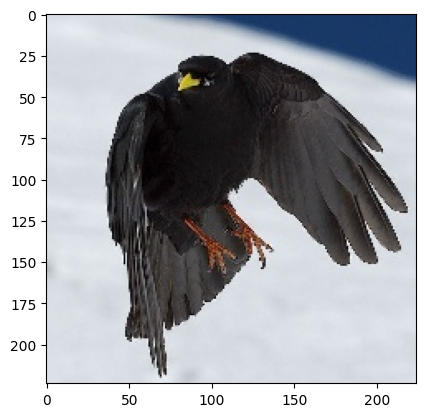

In [18]:
img = cv2.imread(test_path + fold + "/" + img_name)
img = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
print("Species:" , fold)
plt.imshow(img)
plt.show()

In [19]:
img = Image.open(test_path + fold + "/" + img_name)

In [20]:
with torch.no_grad():
    output = fin_model(transform(img).to(device)[None , ...])

In [21]:
torch.max(output , dim = 1)

torch.return_types.max(
values=tensor([-7.8152], device='cuda:0'),
indices=tensor([12], device='cuda:0'))

In [22]:
dir(train_loader)

['_DataLoader__initialized',
 '_DataLoader__multiprocessing_context',
 '_IterableDataset_len_called',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_auto_collation',
 '_dataset_kind',
 '_get_iterator',
 '_index_sampler',
 '_iterator',
 'batch_sampler',
 'batch_size',
 'check_worker_number_rationality',
 'collate_fn',
 'dataset',
 'drop_last',
 'generator',
 'in_order',
 'multiprocessing_context',
 'num_workers',
 'persistent_workers',
 'pin_memory',
 'pin_memory_device',
 'prefetch_factor',
 'sampler',
 'timeout',
 'worker_init_fn']

In [23]:
list(train_dataset.class_to_idx.keys())[215]

'EURASIAN GOLDEN ORIOLE'

In [24]:
# Serialize the final CNN weights to GD
save_path = '/content/drive/MyDrive/bird_resnet18_model.pth'
torch.save(fin_model.state_dict(), save_path)
print(f"Success! Model weights safely serialized to {save_path}")

Success! Model weights safely serialized to /content/drive/MyDrive/bird_resnet18_model.pth


In [25]:
import pandas as pd
import torch
import torch.nn.functional as F

# 1. Put the model in evaluation mode
fin_model.eval()

results = []
# PyTorch ImageFolder automatically maps the folder names to class indices
class_names = test_dataset.classes 

print("Running batch inference on the test set via T4 GPU...")

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        # Move images to the GPU
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = fin_model(images)
        
        # Calculate probabilities and get the highest confidence prediction
        probabilities = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probabilities, 1)
        
        # Retrieve the original file paths for this specific batch
        start_idx = i * test_loader.batch_size
        end_idx = start_idx + images.size(0)
        batch_paths = [test_dataset.samples[j][0] for j in range(start_idx, end_idx)]
        
        # Append the data for each image in the batch
        for j in range(images.size(0)):
            results.append({
                "File Path": batch_paths[j],
                "Actual Species": class_names[labels[j].item()],
                "Predicted Species": class_names[preds[j].item()],
                "Confidence Score (%)": round(confidences[j].item() * 100, 2),
                "Correct Prediction": preds[j].item() == labels[j].item()
            })

# 2. Convert the list of dictionaries to a Pandas DataFrame
df_results = pd.DataFrame(results)

# 3. Calculate overall accuracy just to verify
overall_accuracy = df_results["Correct Prediction"].mean() * 100
print(f"Inference Complete! Overall Test Accuracy: {overall_accuracy:.2f}%")

# 4. Save the comprehensive CSV directly to your mounted Google Drive
csv_path = '/content/drive/MyDrive/bird_test_predictions.csv'
df_results.to_csv(csv_path, index=False)

print(f"Success! {len(df_results)} predictions saved to {csv_path}")

Running batch inference on the test set via T4 GPU...
Inference Complete! Overall Test Accuracy: 89.79%
Success! 2625 predictions saved to /content/drive/MyDrive/bird_test_predictions.csv
